In [1]:
import os
import zipfile
import cv2
import numpy as np

In [2]:
pip install torch torchvision scikit-learn matplotlib numpy pillow tqdm

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 3
EPOCHS = 20
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # ECG images often grayscale
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [8]:
import os
import shutil
import random
# ================= CONFIG =================
SOURCE_DIR = "/content/drive/MyDrive/ECGG"     # your original dataset
DEST_DIR = "dataset"          # new dataset directory

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
random.seed(SEED)

# =========================================

classes = os.listdir(SOURCE_DIR)

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(DEST_DIR, split, cls), exist_ok=True)

for cls in classes:
    class_path = os.path.join(SOURCE_DIR, cls)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "train", cls, img)
        )

    for img in val_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "val", cls, img)
        )

    for img in test_imgs:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(DEST_DIR, "test", cls, img)
        )
print("✅ Dataset split completed successfully!")

✅ Dataset split completed successfully!


In [9]:
train_dir = "/content/dataset/train"
val_dir = "/content/dataset/val"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

In [10]:
from collections import Counter

def count_images(path):
    counts = {}
    for cls in os.listdir(path):
        counts[cls] = len(os.listdir(os.path.join(path, cls)))
    return counts
print("Train:", count_images("/content/dataset/train"))
print("Val:", count_images("/content/dataset/val"))
print("Test:", count_images("/content/dataset/test"))

Train: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382, 'ECG Images of Patient that have History of MI (203)': 142}
Val: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81, 'ECG Images of Patient that have History of MI (203)': 30}
Test: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83, 'ECG Images of Patient that have History of MI (203)': 31}


handling class imbalance


In [11]:
class_counts = np.bincount(train_dataset.targets)
class_weights = 1. / class_counts
sample_weights = class_weights[train_dataset.targets]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
import os

def count_images_per_class(dataset_path):
    class_counts = {}
    for cls in os.listdir(dataset_path):
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len([
                img for img in os.listdir(cls_path)
                if img.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
    return class_counts

print("Train set:", count_images_per_class("/content/dataset/train"))
print("Validation set:", count_images_per_class("/content/dataset/val"))
print("Test set:", count_images_per_class("/content/dataset/test"))

Train set: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382, 'ECG Images of Patient that have History of MI (203)': 142}
Validation set: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81, 'ECG Images of Patient that have History of MI (203)': 30}
Test set: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83, 'ECG Images of Patient that have History of MI (203)': 31}


In [14]:
import numpy as np
from collections import Counter

targets = train_dataset.targets  # class labels
class_counts = Counter(targets)

print("Original class distribution:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count} images")

# Effective sampling per epoch
sampled_indices = list(train_loader.sampler)
sampled_targets = [targets[i] for i in sampled_indices]
sampled_counts = Counter(sampled_targets)
print("\nEffective distribution per epoch (after imbalance handling):")
for cls, count in sampled_counts.items():
    print(f"Class {cls}: {count} samples")

Original class distribution:
Class 0: 142 images
Class 1: 382 images
Class 2: 601 images

Effective distribution per epoch (after imbalance handling):
Class 0: 393 samples
Class 1: 359 samples
Class 2: 373 samples


In [15]:
from collections import Counter

def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        counts[cls] = len(os.listdir(os.path.join(folder, cls)))
    return counts

print("Train:", count_images("/content/dataset/train"))
print("Val:", count_images("/content/dataset/val"))
print("Test:", count_images("/content/dataset/test"))

Train: {'Normal Person ECG Images (859)': 601, 'ECG Images of Patient that have abnormal heart beats (548)': 382, 'ECG Images of Patient that have History of MI (203)': 142}
Val: {'Normal Person ECG Images (859)': 128, 'ECG Images of Patient that have abnormal heart beats (548)': 81, 'ECG Images of Patient that have History of MI (203)': 30}
Test: {'Normal Person ECG Images (859)': 130, 'ECG Images of Patient that have abnormal heart beats (548)': 83, 'ECG Images of Patient that have History of MI (203)': 31}


Device: cuda
Classes: ['ECG Images of Patient that have History of MI (203)', 'ECG Images of Patient that have abnormal heart beats (548)', 'Normal Person ECG Images (859)']
Train labels: {0, 1, 2}
Val labels: {0, 1, 2}
Test labels: {0, 1, 2}
Class distribution: [142 382 601]
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


Epoch [1/20] Train Loss: 1.0061 | Val Loss: 0.8927
Epoch [2/20] Train Loss: 0.7791 | Val Loss: 0.7353
Epoch [3/20] Train Loss: 0.6311 | Val Loss: 0.6474
Epoch [4/20] Train Loss: 0.5123 | Val Loss: 0.6096
Epoch [5/20] Train Loss: 0.4907 | Val Loss: 0.4103
Epoch [6/20] Train Loss: 0.4578 | Val Loss: 0.4885
Epoch [7/20] Train Loss: 0.3909 | Val Loss: 0.3711
Epoch [8/20] Train Loss: 0.3482 | Val Loss: 0.3208
Epoch [9/20] Train Loss: 0.3765 | Val Loss: 0.4235
Epoch [10/20] Train Loss: 0.3801 | Val Loss: 0.3130
Epoch [11/20] Train Loss: 0.3283 | Val Loss: 0.3215
Epoch [12/20] Train Loss: 0.3329 | Val Loss: 0.2961
Epoch [13/20] Train Loss: 0.2981 | Val Loss: 0.3032
Epoch [14/20] Train Loss: 0.3013 | Val Loss: 0.3082
Epoch [15/20] Train Loss: 0.3342 | Val Loss: 0.3459
Epoch [16/20] Train Loss: 0.3339 | Val Loss: 0.3087
Epoch [17/20] Train Loss: 0.2909 | Val Loss: 0.2913
Epoch [18/20] Train Loss: 0.3042 | Val Loss: 0.2859
Epoch [19/20] Train Loss: 0.2980 | Val Loss: 0.3116
Epoch [20/20] Train L

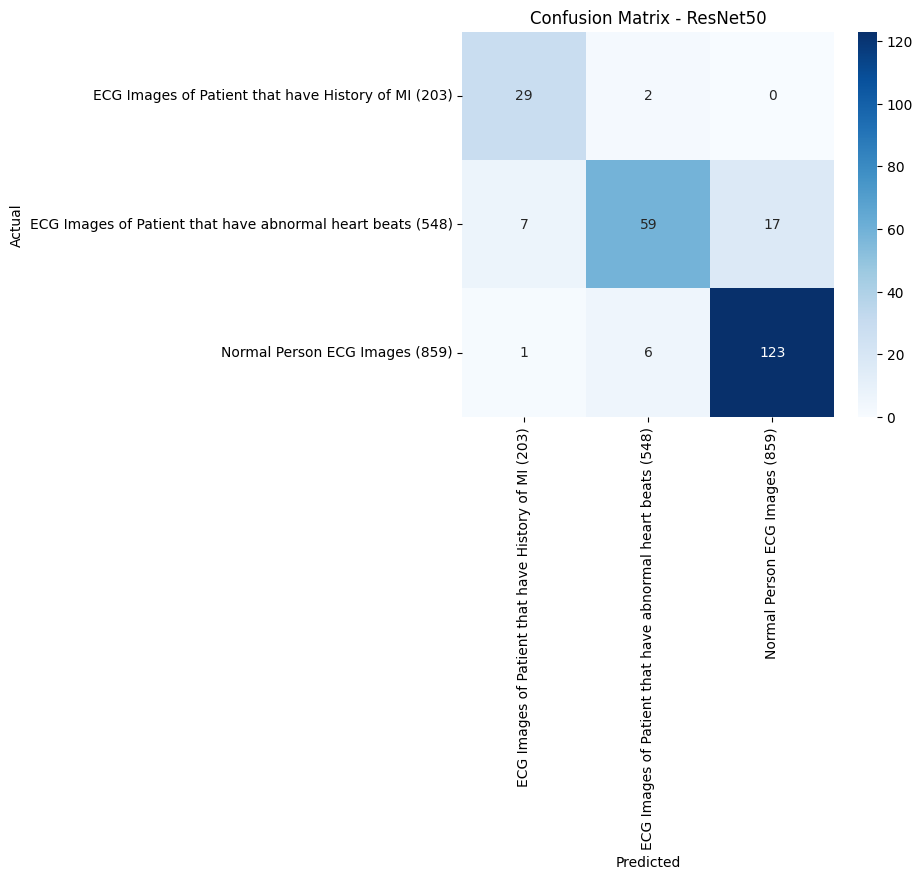

In [16]:
# ==============================
# 0 IMPORTANT FIXES (ADD FIRST)
# ==============================

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # 🔥 shows real CUDA error

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True   # 🔥 handles broken images


# ==============================
# 1 Imports
# ==============================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# ==============================
# 2 Device
# ==============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ==============================
# 3 Transforms (FIXED for ECG)
# ==============================

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),  # ✅ IMPORTANT FIX
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, shear=10, scale=(0.9,1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),  # ✅ IMPORTANT FIX
    transforms.ToTensor()
])


# ==============================
# 4 Load Dataset
# ==============================

train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/val"
test_dir  = "/content/dataset/test"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_transform)

# ✅ Auto classes
NUM_CLASSES = len(train_dataset.classes)

print("Classes:", train_dataset.classes)
print("Train labels:", set(train_dataset.targets))
print("Val labels:", set(val_dataset.targets))
print("Test labels:", set(test_dataset.targets))


# ==============================
# 5 Handle Class Imbalance
# ==============================

targets = train_dataset.targets
class_counts = np.bincount(targets)

print("Class distribution:", class_counts)

weights = 1. / class_counts
samples_weight = np.array([weights[t] for t in targets])

sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)


# ==============================
# 6 Load ResNet50
# ==============================

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze layers
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Replace FC layer
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)

model = model.to(device)


# ==============================
# 7 Loss, Optimizer
# ==============================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.3)


# ==============================
# 8 Training Function
# ==============================

def train_model(model, train_loader, val_loader, epochs=20):

    for epoch in range(epochs):

        # -------- TRAIN --------
        model.train()
        running_loss = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            # ✅ Safety checks
            assert labels.max().item() < NUM_CLASSES
            assert labels.min().item() >= 0

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()

        # -------- VALIDATION --------
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {running_loss/len(train_loader):.4f} | "
              f"Val Loss: {val_loss/len(val_loader):.4f}")


# ==============================
# 9 Train Model
# ==============================

train_model(model, train_loader, val_loader, epochs=20)


# ==============================
# 10 Evaluation Function
# ==============================

def evaluate(model, loader):

    model.eval()

    preds = []
    labels_list = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            labels_list.extend(labels.numpy())

    return labels_list, preds


# ==============================
# 11 Test Evaluation
# ==============================

labels, preds = evaluate(model, test_loader)

print("\nClassification Report:\n")
print(classification_report(labels, preds))

acc = accuracy_score(labels, preds)
print("Test Accuracy:", acc)


# ==============================
# 12 Confusion Matrix
# ==============================

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))

class_names = train_dataset.classes

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet50")

plt.show()

In [ ]:
import torch
import torchvision.models as models

print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

x = torch.randn(1, 3, 224, 224).to(device)

model = models.resnet50()

model = model.to(device)

y = model(x)

print("✅ Everything working fine")

In [ ]:
import torch

print("CUDA:", torch.cuda.is_available())

x = torch.randn(1,3,224,224).cuda()
print("✅ GPU working")

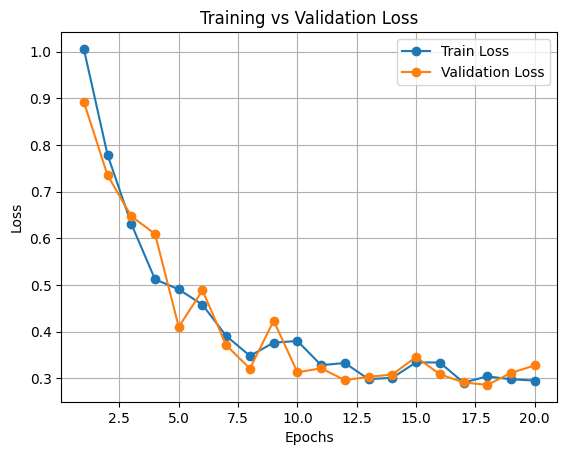

In [17]:
import matplotlib.pyplot as plt

# Data from your output
train_loss = [
    1.0061, 0.7791, 0.6311, 0.5123, 0.4907,
    0.4578, 0.3909, 0.3482, 0.3765, 0.3801,
    0.3283, 0.3329, 0.2981, 0.3013, 0.3342,
    0.3339, 0.2909, 0.3042, 0.2980, 0.2952
]

val_loss = [
    0.8927, 0.7353, 0.6474, 0.6096, 0.4103,
    0.4885, 0.3711, 0.3208, 0.4235, 0.3130,
    0.3215, 0.2961, 0.3032, 0.3082, 0.3459,
    0.3087, 0.2913, 0.2859, 0.3116, 0.3277
]

epochs = range(1, 21)

# Plot
plt.figure()
plt.plot(epochs, train_loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()

plt.show()